# Threads Scraper Analysis Stack — 完整 Pipeline Notebook

逐步實作從 **API 串接 → 爬蟲執行 → 資料 Extract → 受眾分析** 的完整流程。

---

## 架構總覽

```
ScrapeCreators API (/v1/threads/*)
        │  HTTP GET + x-api-key
        ▼
┌─ threads_client.py ──────────────────────┐
│  ThreadsClient._request()   (重試 + 錯誤處理)  │
│  ├─ search_posts()    → list[ThreadsPost]     │
│  ├─ get_profile()     → ThreadsProfile        │
│  ├─ get_user_posts()  → list[ThreadsPost]     │
│  ├─ get_post()        → ThreadsPost           │
│  └─ search_users()    → list[dict]            │
│                                               │
│  ThreadsPost.from_api_response()              │
│  └─ 原始 JSON → 正規化 dataclass               │
└───────────────┬───────────────────────┘
                ▼
┌─ keyword_monitor.py ─────────────────────┐
│  KeywordMonitor                               │
│  ├─ search_keyword()  (去重 by post_id)       │
│  ├─ run_round()       (批次搜多關鍵字)         │
│  └─ export_results()  (CSV + JSON → data/)    │
└───────────────┬───────────────────────┘
                ▼
┌─ Notebook (本檔案) ──────────────────────┐
│  載入 → 語言過濾 → 受眾分群 → 品牌分析        │
└──────────────────────────────────────────┘
```

## Pipeline 節點

| # | 節點 | 說明 |
|---|------|------|
| 1 | 環境設置 | 匯入套件、設定 |
| 2 | API 串接 | 初始化 ThreadsClient、驗證連線 |
| 3 | 爬蟲執行 | 用 KeywordMonitor 批次爬取關鍵字貼文 |
| 4 | 資料 Extract | 檢視 API 原始回傳 → dataclass 解析 → 匯出 |
| 5 | 載入 & 過濾 | 讀取 CSV、繁體中文過濾、清洗 |
| 6 | 受眾輪廓 | 高相關貼文、活躍帳號、關鍵字互動 |
| 7 | 受眾分群 | 求推薦 vs 分享心得、品牌/裝備品類分析 |
| 8 | 洞察總結 | 受眾報告 |

## 節點 1：環境設置

匯入所有需要的套件，包括本專案的 `threads_client` 和 `keyword_monitor`。

In [1]:
import os
import sys
import json
import re
import time
from pathlib import Path
from collections import Counter
from datetime import datetime

from dotenv import load_dotenv
load_dotenv(override=True)  # 讀取 .env 檔案中的環境變數（強制覆蓋）

import pandas as pd
import numpy as np

# 字體設定
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial Unicode MS', 'sans-serif']
matplotlib.rcParams['axes.unicode_minus'] = False

# 顯示設定
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)

# 匯入自定模組
from threads_client import (
    ThreadsClient, ThreadsPost, ThreadsProfile,
    posts_to_dicts, save_json, save_csv,
)
from keyword_monitor import KeywordMonitor

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

# ── 專案設定 ──
PROJECT_TAG = "matador"
KEYWORDS = ["登山裝備", "新手登山", "健行", "攻頂", "登山包"]

print("初始設定完成")
print(f"  - threads_client: ThreadsClient, ThreadsPost, ThreadsProfile")
print(f"  - keyword_monitor: KeywordMonitor")
print(f"  - 輸出目錄: {DATA_DIR.resolve()}")
print(f"  - 專案標記: {PROJECT_TAG}")
print(f"  - 關鍵字: {KEYWORDS}")

初始設定完成
  - threads_client: ThreadsClient, ThreadsPost, ThreadsProfile
  - keyword_monitor: KeywordMonitor
  - 輸出目錄: E:\Fnte Workdir0330\threads-scraper-stack\files\data
  - 專案標記: matador
  - 關鍵字: ['登山裝備', '新手登山', '健行', '攻頂', '登山包']


## 節點 2：API 串接

初始化 `ThreadsClient`，驗證 API Key 與連線狀態。

**API 架構：**
- 底層使用 `requests.Session` 保持連線
- 所有請求透過 `_request()` 統一處理：自動重試（429/500）、錯誤分類（401/402/400）
- Header 帶 `x-api-key` 認證

In [18]:
# ── 初始化 API Client ──
# API Key 設定
API_KEY = os.environ.get("SCRAPECREATORS_API_KEY")

client = ThreadsClient(api_key=API_KEY, timeout=30, max_retries=3)
print("✔ ThreadsClient 初始化成功")
print(f"  - Base URL: https://api.scrapecreators.com")
print(f"  - Timeout: 30s, Max retries: 3")

# 驗證連線：查詢剩餘額度
try:
    balance = client.get_credit_balance()
    print(f"  - API 額度剩餘: {balance} credits")
except Exception as e:
    print(f"  - ⚠ 額度查詢失敗: {e}")

✔ ThreadsClient 初始化成功
  - Base URL: https://api.scrapecreators.com
  - Timeout: 30s, Max retries: 3
  - API 額度剩餘: 33 credits


In [ ]:
# # ── 逐一測試 5 個 API Endpoint ──
# # 每次呼叫消耗 1 credit

# print("=" * 55)
# print("  測試 5 個 Threads API Endpoints")
# print("=" * 55)

# # ── Endpoint 1: 搜尋貼文（核心爬蟲 endpoint）──
# print("\n── 1. search_posts('AI') ──")
# print("   GET /v1/threads/search?query=AI")
# test_posts = client.search_posts(query="AI")
# print(f"   回傳 {len(test_posts)} 筆貼文")
# if test_posts:
#     p = test_posts[0]
#     print(f"   範例: @{p.username} | {p.like_count} likes")
#     print(f"   Text: {p.text[:80]}...")

# # ── Endpoint 2: 用戶 Profile ──
# print("\n── 2. get_profile('zuck') ──")
# print("   GET /v1/threads/profile?handle=zuck")
# try:
#     profile = client.get_profile("zuck")
#     print(f"   @{profile.username} | {profile.full_name}")
#     print(f"   Followers: {profile.follower_count:,} | Verified: {profile.is_verified}")
# except Exception as e:
#     print(f"   Error: {e}")

# # ── Endpoint 3: 用戶貼文列表 ──
# print("\n── 3. get_user_posts('zuck') ──")
# print("   GET /v1/threads/user/posts?handle=zuck")
# try:
#     user_posts = client.get_user_posts("zuck")
#     print(f"   回傳 {len(user_posts)} 筆貼文")
# except Exception as e:
#     print(f"   Error: {e}")

# # ── Endpoint 4: 搜尋用戶 ──
# print("\n── 4. search_users('tech') ──")
# print("   GET /v1/threads/search/users?query=tech")
# try:
#     users = client.search_users("tech")
#     print(f"   回傳 {len(users)} 位用戶")
#     for u in users[:3]:
#         print(f"   @{u.get('username', '?')} — {u.get('follower_count', '?')} followers")
# except Exception as e:
#     print(f"   Error: {e}")

# # ── Endpoint 5: 單篇貼文詳情 ──
# print("\n── 5. get_post(url) ──")
# print("   GET /v1/threads/post?url=...")
# if test_posts and test_posts[0].permalink:
#     try:
#         single = client.get_post(test_posts[0].permalink)
#         print(f"   @{single.username} | {single.like_count} likes | {single.reply_count} replies")
#     except Exception as e:
#         print(f"   Error: {e}")

# print("\n" + "=" * 55)

## 節點 3：爬蟲執行

使用 `KeywordMonitor` 批次爬取多個關鍵字的貼文。

**執行流程：**
```
KeywordMonitor.run_round(keywords)
  → 逐一呼叫 client.search_posts(keyword)
    → _request() → GET /v1/threads/search?query=...
    → API JSON → ThreadsPost.from_api_response() 逐筆解析
  → seen_ids 去重（跨關鍵字 + 跨輪次）
  → 累積到 all_posts[keyword]
  → export_results() → CSV + JSON
```

In [ ]:
# ── 執行關鍵字爬蟲 ──
# 每個關鍵字消耗 1 credit/輪
KEYWORDS = ["登山裝備", "新手登山", "健行", "攻頂", "登山包"]

# 專案標記（用於輸出檔名，例如 matador = 為 Matador 品牌爬取）
PROJECT_TAG = "matador"

monitor = KeywordMonitor(client, output_dir=str(DATA_DIR))

print(f"爬取關鍵字: {KEYWORDS}")
print(f"專案標記: {PROJECT_TAG}")
print(f"輸出目錄: {DATA_DIR}\n")

# 執行 3 輪
for round_num in range(3):
    print(f"\n{'='*40} 第 {round_num+1}/3 輪 {'='*40}")
    monitor.run_round(KEYWORDS)

# ── 合併所有關鍵字，加上 search_keyword 欄，去重後輸出一份 ──
rows = []
for kw, posts in monitor.all_posts.items():
    for p in posts:
        d = posts_to_dicts([p])[0]
        d['search_keyword'] = kw
        rows.append(d)

# 用 post_id 去重
df_out = pd.DataFrame(rows).drop_duplicates(subset='post_id', keep='first')

ts = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_path = DATA_DIR / f"threads_{PROJECT_TAG}_{ts}.csv"
json_path = DATA_DIR / f"threads_{PROJECT_TAG}_{ts}.json"

df_out.to_csv(csv_path, index=False, encoding='utf-8')
save_json(df_out.to_dict(orient='records'), str(json_path))

print(f"\n── 爬取完成 ──")
print(f"  去重後貼文: {len(df_out)} 篇")
print(f"  ✔ {csv_path.name}")
print(f"  ✔ {json_path.name}")

## 節點 4：資料 Extract — 從 API 原始回傳到結構化資料

深入觀察 `ThreadsPost.from_api_response()` 的解析過程：
API 回傳的巢狀 JSON → 正規化的扁平 dataclass。

```
API 原始 JSON (巢狀)              →  ThreadsPost (扁平 dataclass)
─────────────────────                ─────────────────────────────
{                                    post_id:      "12345"
  "id": "12345",                     username:     "user"
  "taken_at": 1700000000,            text:         "Hello..."
  "like_count": 42,                  like_count:   42
  "caption": {"text": "Hello..."},   reply_count:  5
  "text_post_app_info": {            repost_count: 3
    "direct_reply_count": 5,         timestamp:    datetime(UTC)
    "repost_count": 3,               permalink:    "https://..."
    ...                              is_verified:  True
  },                                 ...
  "user": {"username": "user",
           "is_verified": true},
  "code": "ABC123"
}
```

In [ ]:
# # ── 展示 Extract 過程 ──
# # 用一筆模擬的 API 原始回傳，展示 from_api_response() 的解析邏輯

# sample_raw = {
#     "id": "3859605082984152894_67034065080",
#     "pk": "3859605082984152894",
#     "code": "DWQEl-4j_8-",
#     "taken_at": 1711244001,
#     "like_count": 4597,
#     "media_type": 1,
#     "caption": {"text": "1. Claude (solve any problem)\n2. Perplexity (research anything)..."},
#     "text_post_app_info": {
#         "direct_reply_count": 90,
#         "repost_count": 527,
#         "quote_count": 31,
#         "reshare_count": 863,
#         "is_reply": False,
#         "text_fragments": {"fragments": [{"plaintext": "fragment text"}]},
#     },
#     "user": {
#         "username": "duythanhxd",
#         "is_verified": False,
#     },
# }

# print("── 原始 API JSON ──")
# print(json.dumps(sample_raw, ensure_ascii=False, indent=2)[:500])

# print("\n── from_api_response() 解析後 ──")
# parsed = ThreadsPost.from_api_response(sample_raw)
# print(f"  post_id:      {parsed.post_id}")
# print(f"  username:     {parsed.username}")
# print(f"  text:         {parsed.text[:60]}...")
# print(f"  like_count:   {parsed.like_count}")
# print(f"  reply_count:  {parsed.reply_count}")
# print(f"  repost_count: {parsed.repost_count}")
# print(f"  quote_count:  {parsed.quote_count}")
# print(f"  reshare_count:{parsed.reshare_count}")
# print(f"  timestamp:    {parsed.timestamp}")
# print(f"  permalink:    {parsed.permalink}")
# print(f"  is_verified:  {parsed.is_verified}")
# print(f"  is_reply:     {parsed.is_reply}")

# print("\n── posts_to_dicts() → 扁平 dict（可直接轉 DataFrame）──")
# flat = posts_to_dicts([parsed])
# print(json.dumps(flat[0], ensure_ascii=False, indent=2))

# print("\n── 轉為 DataFrame ──")
# pd.DataFrame(flat)

---

## 節點 5：載入資料 & 初步觀察

讀取爬取結果 CSV，執行基礎清洗與資料概覽。

> **語言策略備註：** 本次爬取未使用程式語言過濾。
> 改以關鍵字設計避開日文——使用繁體中文特有字（如「裝備」的「裝」 vs 日文「装」），
> 自然排除多數日文內容。若未來資料出現大量非繁中貼文，可重新啟用語言過濾。

In [11]:
# ── 載入最新爬取結果 ──
csv_pattern = f"threads_{PROJECT_TAG}_*.csv"
matching_csvs = sorted(DATA_DIR.glob(csv_pattern))
if not matching_csvs:
    raise FileNotFoundError(f"找不到 {csv_pattern}，請先執行節點 3 爬蟲")

latest_csv = matching_csvs[-1]
df = pd.read_csv(latest_csv)
print(f"✔ 載入 {latest_csv.name}: {len(df)} 篇\n")

# ── JSON 結構預覽 ──
json_path = latest_csv.with_suffix('.json')
if json_path.exists():
    with open(json_path, 'r', encoding='utf-8') as f:
        raw_json = json.load(f)
    print(f"JSON 欄位: {list(raw_json[0].keys())}")
    print("第一筆預覽:")
    print(json.dumps(raw_json[0], ensure_ascii=False, indent=2)[:500])
    print()

# ── 基礎清洗 ──
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df['text_length'] = df['text'].fillna('').str.len()
engagement_cols = ['like_count', 'reply_count', 'repost_count', 'quote_count', 'reshare_count']
df['total_engagement'] = df[engagement_cols].sum(axis=1)

# 標記每篇貼文命中了哪些關鍵字
for kw in KEYWORDS:
    df[f'has_{kw}'] = df['text'].fillna('').str.contains(kw, case=False)
df['matched_keywords'] = df[[f'has_{kw}' for kw in KEYWORDS]].sum(axis=1)

# ── 初步觀察 ──
print("=== 資料概覽 ===")
print(f"  貼文數: {len(df)}")
print(f"  不重複帳號: {df['username'].nunique()}")
print(f"  時間範圍: {df['timestamp'].min():%Y-%m-%d} ~ {df['timestamp'].max():%Y-%m-%d}")
print(f"  is_reply 分布: {df['is_reply'].value_counts().to_dict()}")

print(f"\n=== search_keyword 來源分布 ===")
print(df['search_keyword'].value_counts().to_string())

print(f"\n=== 互動指標描述統計 ===")
print(df[engagement_cols + ['total_engagement']].describe().round(1).to_string())

print(f"\n=== 前 5 篇貼文預覽 ===")
for _, row in df.head(5).iterrows():
    print(f"  @{row['username']} | {row['total_engagement']:.0f} 互動 | {str(row['text'])[:60]}...")

✔ 載入 threads_matador_20260327_122602.csv: 38 篇

JSON 欄位: ['post_id', 'username', 'is_verified', 'text', 'like_count', 'reply_count', 'repost_count', 'quote_count', 'reshare_count', 'is_reply', 'permalink', 'timestamp', 'search_keyword']
第一筆預覽:
{
  "post_id": "3856259986217855867_77216406325",
  "username": "jjae.0.e_2",
  "is_verified": false,
  "text": "登山包有人要嗎 ？\n懷孕二胎了 沒辦法戶外運動\n就用過兩次 還挺新的 \n還有運動登山服\n有需要的可以帶走喔",
  "like_count": 3,
  "reply_count": 5,
  "repost_count": 1,
  "quote_count": 0,
  "reshare_count": 0,
  "is_reply": false,
  "permalink": "https://www.threads.net/@jjae.0.e_2/post/DWEMAawEWt7",
  "timestamp": "2026-03-19T12:07:15+00:00",
  "search_keyword": "登山裝備"
}

=== 資料概覽 ===
  貼文數: 38
  不重複帳號: 34
  時間範圍: 2024-10-31 ~ 2026-03-27
  is_reply 分布: {False: 38}

=== search_keyword 來源分布 ===
search_keyword
健行      17
新手登山    11
登山裝備    10

=== 互動指標描述統計 ===
       like_count  reply_count  repost_count  quote_count  reshare_count  total_engagement
count        38.0         38.0     

## 節點 6：受眾輪廓分析

In [12]:
# ── 6a: 高相關貼文（命中 2+ 關鍵字）──
# 同時提到「新手登山」+「登山裝備」的貼文 = 最精準的受眾
df_high_match = df[df['matched_keywords'] >= 2].copy()
print(f"命中 2+ 關鍵字的高相關貼文: {len(df_high_match)} 篇\n")

# 關鍵字組合分析
print("── 關鍵字共現組合 ──")
from itertools import combinations
combo_counts = Counter()
for _, row in df_high_match.iterrows():
    matched = [kw for kw in KEYWORDS if row[f'has_{kw}']]
    for combo in combinations(sorted(matched), 2):
        combo_counts[combo] += 1

for combo, count in combo_counts.most_common(10):
    print(f"  {combo[0]} + {combo[1]}: {count} 篇")

# 顯示高相關貼文
print(f"\n── 高相關貼文預覽（依互動排序）──")
cols = ['username', 'is_verified', 'total_engagement', 'like_count', 'text']
preview = df_high_match.nlargest(10, 'total_engagement')[cols].copy()
preview['text'] = preview['text'].str[:80] + '...'
preview.reset_index(drop=True)

命中 2+ 關鍵字的高相關貼文: 0 篇

── 關鍵字共現組合 ──

── 高相關貼文預覽（依互動排序）──


,username,is_verified,total_engagement,like_count,text


In [13]:
# ── 6b: 受眾帳號分析 ──
# 找出最常討論這些主題的用戶 = 潛在受眾 / KOL

user_stats = df.groupby('username').agg(
    貼文數=('post_id', 'count'),
    是否認證=('is_verified', 'first'),
    平均互動=('total_engagement', 'mean'),
    總讚數=('like_count', 'sum'),
    平均命中關鍵字=('matched_keywords', 'mean'),
).round(1)

active_users = user_stats.sort_values('總讚數', ascending=False)

print(f"=== 受眾帳號總覽 ===")
print(f"  不重複帳號: {len(user_stats)}")
print(f"  認證帳號: {user_stats['是否認證'].sum()}")

print(f"\n── Top 15 高影響力帳號（依總讚數）──")
active_users.head(15)

=== 受眾帳號總覽 ===
  不重複帳號: 34
  認證帳號: 0

── Top 15 高影響力帳號（依總讚數）──


,貼文數,是否認證,平均互動,總讚數,平均命中關鍵字
username,,,,,
yz.an_722_,1,False,2220.0,1988,1.0
nini5k6,3,False,696.7,1943,0.7
sundon_basketball,2,False,1034.5,1421,0.5
qiao__0,1,False,3242.0,1257,0.0
05.1ooo,1,False,537.0,497,1.0
evon.90_11,1,False,502.0,402,0.0
johnny_lin_dreamers10,1,False,401.0,358,1.0
sweety19930804,1,False,445.0,355,0.0
team.jingxingshi,1,False,378.0,334,0.0


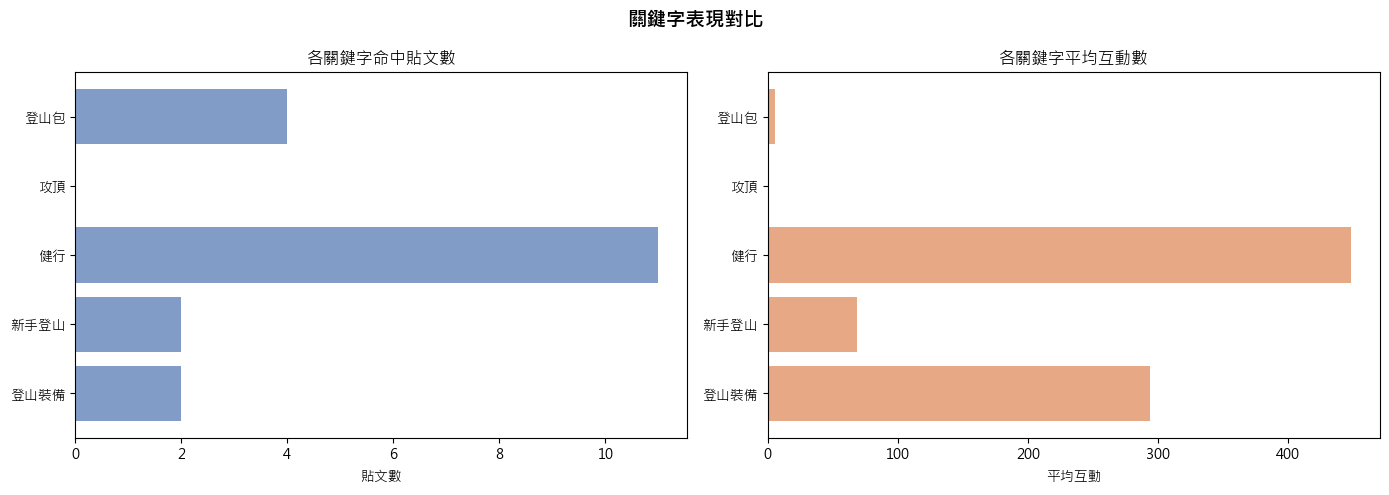

,關鍵字,貼文數,平均互動,平均讚數
0,登山裝備,2,293.500000,257.500000
1,新手登山,2,69.000000,35.000000
2,健行,11,448.181818,392.090909
3,攻頂,0,0.000000,0.000000
4,登山包,4,5.500000,1.750000


In [14]:
# ── 6c: 各關鍵字互動表現 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 各關鍵字的貼文數 & 平均互動
kw_stats = []
for kw in KEYWORDS:
    mask = df[f'has_{kw}']
    subset = df[mask]
    kw_stats.append({
        '關鍵字': kw,
        '貼文數': len(subset),
        '平均互動': subset['total_engagement'].mean() if len(subset) > 0 else 0,
        '平均讚數': subset['like_count'].mean() if len(subset) > 0 else 0,
    })

df_kw_stats = pd.DataFrame(kw_stats)

axes[0].barh(df_kw_stats['關鍵字'], df_kw_stats['貼文數'], color='#4C72B0', alpha=0.7)
axes[0].set_title('各關鍵字命中貼文數', fontsize=12)
axes[0].set_xlabel('貼文數')

axes[1].barh(df_kw_stats['關鍵字'], df_kw_stats['平均互動'], color='#DD8452', alpha=0.7)
axes[1].set_title('各關鍵字平均互動數', fontsize=12)
axes[1].set_xlabel('平均互動')

plt.suptitle('關鍵字表現對比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

df_kw_stats

## 節點 7：受眾分群 & 品牌/裝備分析

In [15]:
# ── 7a: 內容分群 — 貼文是「求推薦」還是「給推薦」？ ──
# 求推薦 = 潛在買家（受眾）；給推薦 = KOL / 商家

asking_patterns = r'(推薦|請問|求推|想問|有沒有|哪裡買|怎麼選|該買|請益|新手問)'
sharing_patterns = r'(分享|開箱|心得|評測|推坑|入手|體驗|使用.*個月|用了)'

df['is_asking'] = df['text'].fillna('').str.contains(asking_patterns, regex=True)
df['is_sharing'] = df['text'].fillna('').str.contains(sharing_patterns, regex=True)

# 分群
def classify_post(row):
    if row['is_asking'] and not row['is_sharing']:
        return '求推薦（潛在買家）'
    elif row['is_sharing'] and not row['is_asking']:
        return '分享心得（KOL/愛好者）'
    elif row['is_asking'] and row['is_sharing']:
        return '混合（邊問邊分享）'
    else:
        return '其他討論'

df['audience_type'] = df.apply(classify_post, axis=1)

print("=== 受眾分群 ===\n")
audience_dist = df['audience_type'].value_counts()
for atype, count in audience_dist.items():
    pct = count / len(df) * 100
    print(f"  {atype}: {count} 篇 ({pct:.1f}%)")

# 各群的互動差異
print("\n=== 各群平均互動 ===\n")
df.groupby('audience_type').agg(
    貼文數=('post_id', 'count'),
    平均讚數=('like_count', 'mean'),
    平均回覆=('reply_count', 'mean'),
    平均互動=('total_engagement', 'mean'),
).round(1).sort_values('平均互動', ascending=False)

=== 受眾分群 ===

  其他討論: 24 篇 (63.2%)
  求推薦（潛在買家）: 11 篇 (28.9%)
  混合（邊問邊分享）: 2 篇 (5.3%)
  分享心得（KOL/愛好者）: 1 篇 (2.6%)

=== 各群平均互動 ===



C:\Users\Rex\AppData\Local\Temp\ipykernel_22904\3693049315.py:7: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['is_asking'] = df['text'].fillna('').str.contains(asking_patterns, regex=True)
C:\Users\Rex\AppData\Local\Temp\ipykernel_22904\3693049315.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df['is_sharing'] = df['text'].fillna('').str.contains(sharing_patterns, regex=True)


,貼文數,平均讚數,平均回覆,平均互動
audience_type,,,,
求推薦（潛在買家）,11,189.2,62.6,420.2
其他討論,24,338.3,19.5,411.6
混合（邊問邊分享）,2,185.0,44.5,231.5
分享心得（KOL/愛好者）,1,5.0,0.0,5.0


In [16]:
# ── 7b: 品牌 & 裝備品類提及分析 ──
# 看受眾在討論哪些品牌和品類

brand_patterns = {
    '迪卡儂/Decathlon': r'(迪卡儂|decathlon)',
    'The North Face': r'(north face|北臉|TNF)',
    'mont-bell': r'(mont.?bell)',
    'Merrell': r'(merrell)',
    'Salomon': r'(salomon)',
    'Columbia': r'(columbia|哥倫比亞)',
    'Mammut': r'(mammut|長毛象)',
    "Arc'teryx": r"(arc.?teryx|始祖鳥)",
    'HOKA': r'(hoka)',
    'Osprey': r'(osprey)',
}

gear_patterns = {
    '登山鞋/靴': r'(登山鞋|登山靴|健行鞋|防水鞋|gore.?tex.*鞋)',
    '背包': r'(背包|登山包)',
    '雨衣/風衣': r'(雨衣|風衣|防水外套|衝鋒衣)',
    '登山杖': r'(登山杖|手杖|trekking pole)',
    '排汗衣/底層': r'(排汗|底層|機能衣|速乾)',
    '帳篷/睡袋': r'(帳篷|睡袋|露宿)',
    '頭燈': r'(頭燈|照明)',
}

print("=== 品牌提及排名 ===\n")
brand_counts = {}
for name, pattern in brand_patterns.items():
    count = df['text'].fillna('').str.contains(pattern, case=False, regex=True).sum()
    if count > 0:
        brand_counts[name] = count
for name, count in sorted(brand_counts.items(), key=lambda x: -x[1]):
    print(f"  {name}: {count} 篇")
if not brand_counts:
    print("  （無品牌提及）")

print("\n=== 裝備品類提及排名 ===\n")
gear_counts = {}
for name, pattern in gear_patterns.items():
    count = df['text'].fillna('').str.contains(pattern, case=False, regex=True).sum()
    if count > 0:
        gear_counts[name] = count
for name, count in sorted(gear_counts.items(), key=lambda x: -x[1]):
    print(f"  {name}: {count} 篇")
if not gear_counts:
    print("  （無品類提及）")

=== 品牌提及排名 ===

  （無品牌提及）

=== 裝備品類提及排名 ===

  背包: 5 篇
  登山鞋/靴: 2 篇
  頭燈: 2 篇


C:\Users\Rex\AppData\Local\Temp\ipykernel_22904\83160215.py:30: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  count = df['text'].fillna('').str.contains(pattern, case=False, regex=True).sum()
C:\Users\Rex\AppData\Local\Temp\ipykernel_22904\83160215.py:41: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  count = df['text'].fillna('').str.contains(pattern, case=False, regex=True).sum()


## 節點 8：受眾洞察總結

In [17]:
# ── 受眾洞察總結 ──
print("=" * 60)
print("  受眾洞察報告")
print("=" * 60)

print(f"\n--- 資料概況 ---")
print(f"  專案標記: {PROJECT_TAG}")
print(f"  搜尋關鍵字: {KEYWORDS}")
print(f"  去重後貼文: {len(df)} 篇")
print(f"  不重複帳號: {df['username'].nunique()}")
print(f"  高相關貼文（2+ 關鍵字命中）: {len(df_high_match)} 篇")

print(f"\n--- 受眾分群 ---")
for atype, count in df['audience_type'].value_counts().items():
    print(f"  {atype}: {count} 篇")

# 潛在買家帳號
buyers = df[df['audience_type'] == '求推薦（潛在買家）']
print(f"\n--- 潛在買家帳號（{len(buyers)} 篇求推薦貼文）---")
for _, row in buyers.iterrows():
    print(f"  @{row['username']}: {str(row['text'])[:60]}...")

# KOL / 分享者
sharers = df[df['audience_type'].isin(['分享心得（KOL/愛好者）', '混合（邊問邊分享）'])]
sharers_sorted = sharers.sort_values('total_engagement', ascending=False)
print(f"\n--- KOL / 分享者帳號（依互動排序）---")
for _, row in sharers_sorted.head(10).iterrows():
    print(f"  @{row['username']}: {row['total_engagement']:.0f} 互動 | {str(row['text'])[:50]}...")

# 品牌 & 品類 top
if brand_counts:
    print(f"\n--- 熱門品牌 ---")
    for name, count in sorted(brand_counts.items(), key=lambda x: -x[1])[:5]:
        print(f"  {name}: {count} 篇")

if gear_counts:
    print(f"\n--- 熱門裝備品類 ---")
    for name, count in sorted(gear_counts.items(), key=lambda x: -x[1])[:5]:
        print(f"  {name}: {count} 篇")

print("\n" + "=" * 60)

  受眾洞察報告

--- 資料概況 ---
  專案標記: matador
  搜尋關鍵字: ['登山裝備', '新手登山', '健行', '攻頂', '登山包']
  去重後貼文: 38 篇
  不重複帳號: 34
  高相關貼文（2+ 關鍵字命中）: 0 篇

--- 受眾分群 ---
  其他討論: 24 篇
  求推薦（潛在買家）: 11 篇
  混合（邊問邊分享）: 2 篇
  分享心得（KOL/愛好者）: 1 篇

--- 潛在買家帳號（11 篇求推薦貼文）---
  @shiji_zapie: 初入坑的新手登山小白，裝備就想直接輕量化是安全的嗎🥹

我其實很討厭爬山，但為了人生清單打勾勾，可能要暫時入坑一下，有沒...
  @377347_09: 請問脆友們 有推薦頭燈嗎？
登山裝備 
我的兩小時就陣亡了...
  @kose_6786: 請熱愛爬山脆友們幫忙推薦新手登山鞋
或是穿過覺得不錯的推薦
台中哪裡可以買登山鞋呢？
想找款式比較多的店家“謝謝大家...
  @1985miller: 身為一個剛入山林的小菜雞，
靠著自己爬文看推薦買齊裝備～
究竟花費多少呢？
-
有沒有人算出來
我總共花了多少錢💸
-
...
  @fafa.__.03: 脆好多登山大神！跟登山漂亮女森
但我只是個剛起步的小菜鳥🥹

想找一樣新手、可以慢慢爬山的朋友
女生一起更安心💛

但私...
  @kelly0805960: 請教各位登山前輩
有推薦好用的頭燈嗎...
  @shadowring1011: 還有沒有登山新手想進群組跟團呢？
老手也歡迎進來揪團
小弟經營的登山群
除了不定期開團外
也會開課教學各種登山知識和技能...
  @f20910: 最近想爬山 
嗨～我是登山新手 👣
想從小百岳開始練習，
這週六。9/6（六）計畫爬土城天上山。

想問看看有沒有山友一...
  @sui.zzz0: 我想開始嘗試健走或爬山，但目前是完全的新手，希望能從難度較低、路線簡單的地方開始。請問有哪些適合初學者的健走或登山地點推...
  @ziziwonttired: 想問有沒有人推薦最好走的步道
目前只有涉略象山
也有上網看別人介紹或是有下載健行筆記～

想要～
1.適合一個人
2.當...
  @qiao__0: 求推薦有沒有台中算命 問事很準的
都不用說他都會知道的那種

In [23]:
test_data = df[['username', 'text', 'permalink', 'search_keyword', 'audience_type']]
df.to_csv("./threads_test_data.csv", index=False, encoding='utf-8')

In [21]:
print(test_data)


                 username                                                                             text                                                        permalink search_keyword  \
0              jjae.0.e_2                        登山包有人要嗎 ？\n懷孕二胎了 沒辦法戶外運動\n就用過兩次 還挺新的 \n還有運動登山服\n有需要的可以帶走喔             https://www.threads.net/@jjae.0.e_2/post/DWEMAawEWt7           登山裝備   
1             shiji_zapie  初入坑的新手登山小白，裝備就想直接輕量化是安全的嗎🥹\n\n我其實很討厭爬山，但為了人生清單打勾勾，可能要暫時入坑一下，有沒有還在坑裡或已退坑的大大給點...            https://www.threads.net/@shiji_zapie/post/DMFApjlP2wq           登山裝備   
2             elk.1524887                                  因身體原因無法再進行長運動 家裡還有幾套戶外裝備 有興趣的可追蹤私訊我領走 圖片這些全部不用💰            https://www.threads.net/@elk.1524887/post/DQ9Ws9Kj4dW           登山裝備   
3               377347_09                                                  請問脆友們 有推薦頭燈嗎？\n登山裝備 \n我的兩小時就陣亡了              https://www.threads.net/@377347_09/post/DLi7YFvTmEq           登山裝備   
4               kose_6786                    請熱愛爬山